# HITO 3 - Modelado, Experimentacion y Validacion
## Asignatura: Desarrollo e Integracion de Servicios de IA (DISIA)
### Proyecto: Deteccion de Intrusos en Sistemas IIoT (X-IIoTID)

En este cuaderno se desarrolla la fase de **modelado, experimentacion y validacion** siguiendo la metodologia **CRISP-DM** sobre el conjunto de datos ya preprocesado en el Hito 2.

El objetivo es que toda la logica del Hito 3 pueda entenderse leyendo unicamente este notebook: que modelos forman parte del estudio, que significa cada arquitectura, que protocolo experimental se adopta como referencia, que metricas se recalculan y que conclusiones justifican la seleccion final del modelo.

A nivel practico, el cuaderno trabaja con las particiones finales `X_train_final`, `X_val_final` y `X_test_final`, junto con los artefactos experimentales ya disponibles para este hito: etiquetas reales del conjunto de prueba, predicciones generadas por cada modelo y tablas de resultados consolidadas. A partir de ellos, se generan de nuevo las salidas auxiliares del Hito 3 en forma de tablas, rankings y figuras exportadas.

### Objetivos concretos del notebook
1. Documentar de forma clara los **modelos candidatos** incluidos en la comparativa.
2. Explicar las **arquitecturas experimentales** consideradas y justificar cual se toma como referencia.
3. Recalcular y validar las metricas principales en los tres niveles del problema: `class3`, `class2` y `class1`.
4. Analizar el comportamiento global y detallado de los mejores modelos.
5. Generar artefactos reutilizables para la memoria: tablas resumen, rankings y matrices de confusion legibles.

### Nota metodologica
El entrenamiento de los modelos forma parte del diseno experimental que se consolida en este hito. En este cuaderno no se repite el ajuste completo desde cero, sino que se **documentan, validan y analizan** sus resultados experimentales bajo un protocolo comun, garantizando comparabilidad y trazabilidad.

---
### Indice del cuaderno:
1. [Carga de datos y generacion de artefactos del notebook](#1)
2. [Modelos seleccionados y protocolo experimental de referencia](#2)
3. [Taxonomia de ataques y funciones de evaluacion](#3)
4. [Recomputacion de metricas por modelo](#4)
5. [Comparativa global de resultados](#5)
6. [Analisis detallado de los mejores modelos](#6)
7. [Conclusiones del modelado](#7)


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = lambda x: f"{x:.4f}"


### 1. Carga de datos y generacion de artefactos del notebook <a name="1"></a>

En esta primera parte se organizan los materiales con los que trabaja el Hito 3. El flujo de artefactos queda dividido en dos bloques:

1. **Entradas experimentales**: matrices finales del Hito 2, etiquetas reales del conjunto de prueba, predicciones generadas por cada modelo y tablas de referencia.
2. **Salidas generadas por este notebook**: resumentes de particiones, catalogos de modelos y arquitecturas, metricas recalculadas, rankings, reportes por modelo y figuras exportadas.

Todas las salidas nuevas se guardan en la carpeta `ARTEFACTOS_HITO3/salidas_notebook`, de modo que el propio cuaderno deja preparada la documentacion reutilizable para la memoria.


In [2]:
ROOT = Path.cwd()
DATA_DIR = ROOT / 'DATA'
ARTEFACTS_DIR = ROOT / 'ARTEFACTOS_HITO3'
MODEL_PRED_DIR = ARTEFACTS_DIR / 'predicciones_modelos'
OUTPUT_DIR = ARTEFACTS_DIR / 'salidas_notebook'
TABLES_DIR = OUTPUT_DIR / 'tablas'
FIGURES_DIR = OUTPUT_DIR / 'figuras'

for directory in [OUTPUT_DIR, TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

X_train = pd.read_csv(DATA_DIR / 'X_train_final.csv')
X_val = pd.read_csv(DATA_DIR / 'X_val_final.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test_final.csv')

real = pd.read_csv(ARTEFACTS_DIR / 'real.csv', header=None, names=['class3', 'class2', 'class1'])
resultados_referencia = pd.read_excel(ARTEFACTS_DIR / 'resultados_modelos.xlsx')
arquitecturas_referencia = pd.read_excel(ARTEFACTS_DIR / 'comparacion_arquitecturas.xlsx')

split_summary = pd.DataFrame(
    {
        'conjunto': ['X_train_final', 'X_val_final', 'X_test_final'],
        'filas': [len(X_train), len(X_val), len(X_test)],
        'columnas': [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
    }
)

artifact_inventory = pd.DataFrame(
    [
        ['Entrada', 'Matrices finales', 'Variables de entrada ya depuradas y seleccionadas en el Hito 2.', str(DATA_DIR)],
        ['Entrada', 'Etiquetas reales de test', 'Fichero con las salidas reales `class3`, `class2` y `class1` del conjunto de prueba.', str(ARTEFACTS_DIR / 'real.csv')],
        ['Entrada', 'Predicciones por modelo', 'Predicciones finales generadas por cada modelo comparado en el estudio.', str(MODEL_PRED_DIR)],
        ['Entrada', 'Tablas de referencia', 'Resumen de resultados y comparativa entre arquitecturas.', str(ARTEFACTS_DIR)],
        ['Salida', 'Tablas auxiliares', 'CSVs generados por el notebook con metricas, rankings y reportes.', str(TABLES_DIR)],
        ['Salida', 'Figuras', 'Graficas y matrices de confusion exportadas por el notebook.', str(FIGURES_DIR)],
    ],
    columns=['tipo', 'artefacto', 'descripcion', 'ruta'],
)

display(split_summary)
display(artifact_inventory)

split_summary.to_csv(TABLES_DIR / 'resumen_particiones.csv', index=False)
artifact_inventory.to_csv(TABLES_DIR / 'inventario_artefactos.csv', index=False)

print(f'Numero de etiquetas reales disponibles para test: {len(real):,}'.replace(',', '.'))
print(f'Numero de modelos con predicciones guardadas: {len(list(MODEL_PRED_DIR.glob("*.csv")))}')
print(f'Salidas generadas por el notebook: {OUTPUT_DIR}')


,conjunto,filas,columnas
0,X_train_final,574583,34
1,X_val_final,123125,34
2,X_test_final,123126,34


,tipo,artefacto,descripcion,ruta
0,Entrada,Matrices finales,Variables de entrada ya depuradas y selecciona...,C:\Users\usuario\Desktop\MARCELO\MASTER\DSIA\DATA
1,Entrada,Etiquetas reales de test,"Fichero con las salidas reales `class3`, `clas...",C:\Users\usuario\Desktop\MARCELO\MASTER\DSIA\A...
2,Entrada,Predicciones por modelo,Predicciones finales generadas por cada modelo...,C:\Users\usuario\Desktop\MARCELO\MASTER\DSIA\A...
3,Entrada,Tablas de referencia,Resumen de resultados y comparativa entre arqu...,C:\Users\usuario\Desktop\MARCELO\MASTER\DSIA\A...
4,Salida,Tablas auxiliares,"CSVs generados por el notebook con metricas, r...",C:\Users\usuario\Desktop\MARCELO\MASTER\DSIA\A...
5,Salida,Figuras,Graficas y matrices de confusion exportadas po...,C:\Users\usuario\Desktop\MARCELO\MASTER\DSIA\A...


Numero de etiquetas reales disponibles para test: 123.126
Numero de modelos con predicciones guardadas: 7
Salidas generadas por el notebook: C:\Users\usuario\Desktop\MARCELO\MASTER\DSIA\ARTEFACTOS_HITO3\salidas_notebook


In [3]:
distribution_summary = pd.DataFrame(
    {
        'class3 (binaria)': real['class3'].value_counts().sort_index(),
    }
)

category_counts = real['class2'].value_counts().rename('frecuencia').to_frame()
type_counts = real['class1'].value_counts().rename('frecuencia').to_frame()

display(distribution_summary)
display(category_counts.head(10))
display(type_counts.head(15))


,class3 (binaria)
class3,
0,63213
1,59913


,frecuencia
class2,
Normal,63213
RDOS,21095
Reconnaissance,19130
Weaponization,10166
Lateral _movement,4805
Exfiltration,3291
Tampering,754
C&C,437
Exploitation,162


,frecuencia
class1,
Normal,63213
RDOS,21095
Scanning_vulnerability,7921
Generic_scanning,7559
BruteForce,7152
MQTT_cloud_broker_subscription,3546
Discovering_resources,3447
Exfiltration,3291
insider_malcious,2638


Las particiones finales conservan las **34 caracteristicas** resultantes del pipeline de preprocesamiento definido en el Hito 2. Ademas, la distribucion de `class2` y `class1` mantiene el fuerte desbalanceo detectado previamente, lo que justifica el uso de metricas macro y de variantes balanceadas en varias de las arquitecturas comparadas.

### 2. Modelos seleccionados y protocolo experimental de referencia <a name="2"></a>

Antes de comparar resultados concretos, conviene dejar claro **que se compara** y **bajo que diseno experimental**. En este trabajo se distinguen dos niveles:

1. **Modelos candidatos**: algoritmos clasicos y modelos profundos que se someten a comparacion.
2. **Arquitecturas experimentales**: forma en que se organiza la prediccion de las tres salidas (`class3`, `class2`, `class1`) y como se incorpora el balanceo de clases.

La comparacion reproducible de este notebook se centra en los **siete modelos con predicciones almacenadas** en los artefactos del Hito 3: `DT`, `RF`, `NB`, `KNN`, `LR`, `DNN` y `GRU`.

En este contexto, una **arquitectura** no es un modelo concreto, sino una estrategia global para estructurar la tarea de clasificacion:

1. **Arquitectura 1**: cascada jerarquica binaria -> categoria -> tipo.
2. **Arquitectura 2**: clasificacion directa del tipo final (`class1`), incluyendo `Normal` como una clase mas.
3. **Arquitectura 3**: clasificacion por categoria (`class2`) incluyendo `Normal`, seguida de una clasificacion por tipo dentro de las categorias anomalas.

Las variantes **balanceadas** aplican pesos de clase para reducir el sesgo hacia las clases mayoritarias. Sobre ese marco comun se decide que protocolo se toma como referencia para el resto del analisis.


#### Modelos incluidos en la comparativa

,modelo,familia,tipo,motivo_de_inclusion
0,DT,Aprendizaje automatico,Arbol de decision,Modelo interpretable y buen punto de comparaci...
1,RF,Aprendizaje automatico,Bosque aleatorio,"Modelo basado en arboles, robusto y adecuado p..."
2,NB,Aprendizaje automatico,Naive Bayes gaussiano,Baseline probabilistico simple para contrastar...
3,KNN,Aprendizaje automatico,k-Nearest Neighbors,Baseline no parametrico sensible a estructura ...
4,LR,Aprendizaje automatico,Regresion logistica,Baseline lineal util para medir cuanto afecta ...
5,DNN,Aprendizaje profundo,Red neuronal densa,Referencia profunda para datos tabulares ya ag...
6,GRU,Aprendizaje profundo,Red recurrente GRU,Contraste profundo para analizar si una arquit...


#### Significado de las arquitecturas experimentales

,elemento,descripcion,implicacion_experimental
0,Arquitectura 1,"Cascada jerarquica: primero `class3`, despues ...",Descompone el problema en etapas sucesivas y r...
1,Arquitectura 2,"Clasificacion directa de `class1`, incluyendo ...",Simplifica el flujo experimental y evita propa...
2,Arquitectura 3,"Clasificacion de `class2` incluyendo `Normal`,...","Mantiene estructura jerarquica, pero con una p..."
3,Version balanceada,"Mismo flujo que la arquitectura base, incorpor...",Compensa parcialmente el fuerte desbalanceo en...


#### Comparativa cuantitativa entre arquitecturas

,metrica,Arquitectura 1,Arquitectura 2,Arquitectura 3,Arquitectura 1 balanceada,Arquitectura 2 balanceada,Arquitectura 3 balanceada
0,Accuracy,0.9937,0.9938,0.9937,0.9937,0.9940,0.9939
1,Precision,0.9225,0.9491,0.9490,0.9429,0.9550,0.9406
2,Recall,0.9302,0.9314,0.9347,0.9294,0.9344,0.9334
3,F1,0.9261,0.9383,0.9400,0.9342,0.9429,0.9346


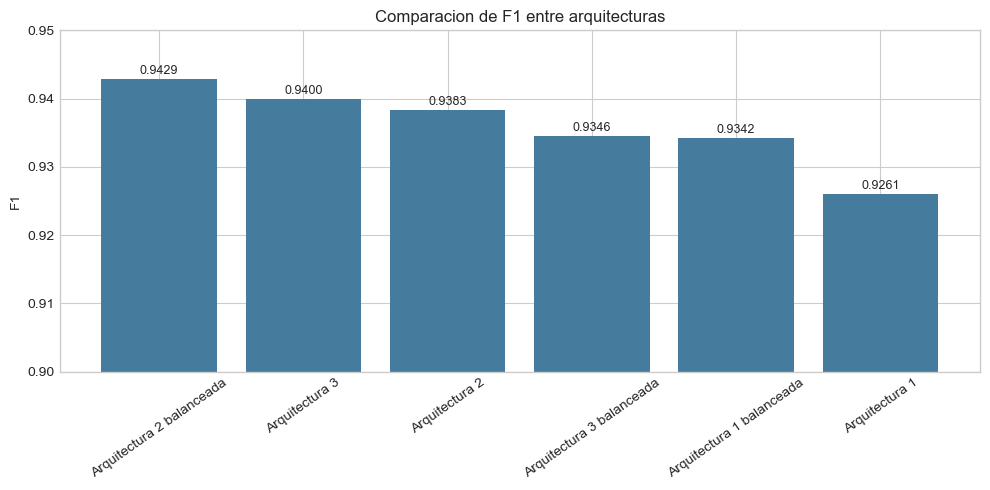

**Arquitectura seleccionada como referencia:** Arquitectura 2 balanceada (F1 = 0.9429).

In [4]:
model_inventory = pd.DataFrame(
    [
        ['DT', 'Aprendizaje automatico', 'Arbol de decision', 'Modelo interpretable y buen punto de comparacion para datos tabulares no lineales.'],
        ['RF', 'Aprendizaje automatico', 'Bosque aleatorio', 'Modelo basado en arboles, robusto y adecuado para explotar interacciones complejas entre variables.'],
        ['NB', 'Aprendizaje automatico', 'Naive Bayes gaussiano', 'Baseline probabilistico simple para contrastar frente a modelos mas flexibles.'],
        ['KNN', 'Aprendizaje automatico', 'k-Nearest Neighbors', 'Baseline no parametrico sensible a estructura local del espacio de caracteristicas.'],
        ['LR', 'Aprendizaje automatico', 'Regresion logistica', 'Baseline lineal util para medir cuanto afecta la no linealidad del problema.'],
        ['DNN', 'Aprendizaje profundo', 'Red neuronal densa', 'Referencia profunda para datos tabulares ya agregados.'],
        ['GRU', 'Aprendizaje profundo', 'Red recurrente GRU', 'Contraste profundo para analizar si una arquitectura recurrente aporta ventaja adicional.'],
    ],
    columns=['modelo', 'familia', 'tipo', 'motivo_de_inclusion'],
)

architecture_inventory = pd.DataFrame(
    [
        ['Arquitectura 1', 'Cascada jerarquica: primero `class3`, despues `class2` y finalmente `class1` solo en las anomalias detectadas.', 'Descompone el problema en etapas sucesivas y reduce la complejidad por nivel.'],
        ['Arquitectura 2', 'Clasificacion directa de `class1`, incluyendo `Normal` como clase final.', 'Simplifica el flujo experimental y evita propagar errores entre etapas.'],
        ['Arquitectura 3', 'Clasificacion de `class2` incluyendo `Normal`, seguida de clasificacion de `class1` dentro de cada categoria anomala.', 'Mantiene estructura jerarquica, pero con una primera decision multiclase mas rica que la binaria.'],
        ['Version balanceada', 'Mismo flujo que la arquitectura base, incorporando pesos de clase.', 'Compensa parcialmente el fuerte desbalanceo entre clases frecuentes y raras.'],
    ],
    columns=['elemento', 'descripcion', 'implicacion_experimental'],
)

display(Markdown('#### Modelos incluidos en la comparativa'))
display(model_inventory)
display(Markdown('#### Significado de las arquitecturas experimentales'))
display(architecture_inventory)

model_inventory.to_csv(TABLES_DIR / 'catalogo_modelos.csv', index=False)
architecture_inventory.to_csv(TABLES_DIR / 'catalogo_arquitecturas.csv', index=False)

arquitecturas_df = (
    arquitecturas_referencia.iloc[:4, :7]
    .rename(columns={'Columna1': 'metrica'})
    .dropna(how='all')
)

display(Markdown('#### Comparativa cuantitativa entre arquitecturas'))
display(arquitecturas_df)

arquitecturas_df.to_csv(TABLES_DIR / 'comparativa_arquitecturas.csv', index=False)

f1_arquitecturas = (
    arquitecturas_df[arquitecturas_df['metrica'] == 'F1']
    .melt(id_vars='metrica', var_name='arquitectura', value_name='valor')
    .sort_values('valor', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(f1_arquitecturas['arquitectura'], f1_arquitecturas['valor'], color='#457b9d')
ax.set_title('Comparacion de F1 entre arquitecturas')
ax.set_ylabel('F1')
ax.set_ylim(0.90, 0.95)
ax.tick_params(axis='x', rotation=35)
for idx, value in enumerate(f1_arquitecturas['valor']):
    ax.text(idx, value + 0.0003, f'{value:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'comparacion_f1_arquitecturas.png', dpi=220, bbox_inches='tight')
plt.show()

best_arch = f1_arquitecturas.iloc[0]
display(Markdown(
    f"**Arquitectura seleccionada como referencia:** {best_arch['arquitectura']} (F1 = {best_arch['valor']:.4f})."
))


La comparativa anterior muestra que **Arquitectura 2 balanceada** ofrece el mejor compromiso global. Esto significa que el protocolo de referencia para el resto del analisis es una **clasificacion directa del tipo final de ataque (`class1`) incorporando balanceo de clases**.

Esta eleccion es coherente con el problema estudiado por tres motivos:

1. Evita el encadenamiento de errores propio de las arquitecturas jerarquicas.
2. Permite comparar todos los modelos sobre una misma tarea final y un mismo espacio de 34 variables.
3. Atiende el desbalanceo entre clases, especialmente importante en tipos minoritarios como `fuzzing`, `TCP Relay` o `C&C`.

Dentro de ese protocolo comun, los modelos profundos evaluados en el estudio son:

1. **DNN** con tres capas densas de 200 neuronas, activacion ReLU, salida `softmax`, optimizador `RMSprop`, `batch_size = 250`, `epochs = 10` y pesos de clase.
2. **GRU** con tres capas recurrentes GRU de 200 unidades, salida `softmax`, optimizador `RMSprop`, `batch_size = 250`, `epochs = 10` y pesos de clase.

Los modelos clasicos disponibles para la comparativa reproducible del cuaderno son `DT`, `RF`, `NB`, `KNN` y `LR`. Todos ellos se analizan sobre las mismas particiones y bajo las mismas metricas, de forma que las diferencias observadas puedan atribuirse al comportamiento del modelo y no a cambios en los datos.


### 3. Taxonomia de ataques y funciones de evaluacion <a name="3"></a>

Las predicciones almacenadas por modelo corresponden al **tipo de ataque final** (`class1`). A partir de esa salida se derivan tambien:

1. La clasificacion binaria (`class3`): `Normal` frente a `Attack`.
2. La clasificacion por categoria (`class2`): `Reconnaissance`, `Weaponization`, etc.

Esto permite evaluar cada modelo en los tres niveles de decision del problema.


In [5]:
anomalias = {
    'Reconnaissance': ['Generic_scanning', 'Scanning_vulnerability', 'fuzzing', 'Discovering_resources'],
    'Weaponization': ['BruteForce', 'Dictionary', 'insider_malcious'],
    'Exploitation': ['Reverse_shell', 'MitM'],
    'Lateral _movement': ['MQTT_cloud_broker_subscription', 'Modbus_register_reading', 'TCP Relay'],
    'C&C': ['C&C'],
    'Exfiltration': ['Exfiltration'],
    'Tampering': ['False_data_injection', 'Fake_notification'],
    'crypto-ransomware': ['crypto-ransomware'],
    'RDOS': ['RDOS'],
    'Normal': ['Normal'],
}

tipo_a_categoria = {
    tipo: categoria
    for categoria, tipos in anomalias.items()
    for tipo in tipos
}


def load_prediction_file(path: Path) -> pd.Series:
    return pd.read_csv(path, header=None).iloc[:, 0]


def derive_outputs(pred_type: pd.Series) -> tuple[pd.Series, pd.Series]:
    pred_category = pred_type.map(tipo_a_categoria)
    pred_binary = (pred_type != 'Normal').astype(int)
    return pred_binary, pred_category


def evaluate_predictions(model_name: str, pred_type: pd.Series) -> dict:
    pred_binary, pred_category = derive_outputs(pred_type)
    return {
        'modelo': model_name,
        'acc_bin': accuracy_score(real['class3'], pred_binary),
        'prec_bin': precision_score(real['class3'], pred_binary, average='binary', zero_division=0),
        'rec_bin': recall_score(real['class3'], pred_binary, average='binary', zero_division=0),
        'f1_bin': f1_score(real['class3'], pred_binary, average='binary', zero_division=0),
        'acc_cat': accuracy_score(real['class2'], pred_category),
        'prec_cat': precision_score(real['class2'], pred_category, average='macro', zero_division=0),
        'rec_cat': recall_score(real['class2'], pred_category, average='macro', zero_division=0),
        'f1_cat': f1_score(real['class2'], pred_category, average='macro', zero_division=0),
        'acc_type': accuracy_score(real['class1'], pred_type),
        'prec_type': precision_score(real['class1'], pred_type, average='macro', zero_division=0),
        'rec_type': recall_score(real['class1'], pred_type, average='macro', zero_division=0),
        'f1_type': f1_score(real['class1'], pred_type, average='macro', zero_division=0),
    }


def classification_report_df(y_true: pd.Series, y_pred: pd.Series) -> pd.DataFrame:
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return pd.DataFrame(report).T


def model_display_name(model_name: str) -> str:
    mapping = {
        'DecisionTreeClassifier': 'DT',
        'RandomForestClassifier': 'RF',
        'GaussianNB': 'NB',
        'KNeighborsClassifier': 'KNN',
        'LogisticRegression': 'LR',
        'DNN': 'DNN',
        'GRU': 'GRU',
    }
    return mapping.get(model_name, model_name)


### 4. Recomputacion de metricas por modelo <a name="4"></a>

A continuacion se recalculan las metricas de todos los modelos disponibles a partir de sus predicciones reales sobre el conjunto de prueba. Esto permite verificar que la tabla consolidada de referencia es consistente y, al mismo tiempo, disponer de estructuras reutilizables para el analisis posterior.


In [6]:
prediction_files = sorted(MODEL_PRED_DIR.glob('*.csv'))
model_predictions = {path.stem: load_prediction_file(path) for path in prediction_files}

metric_rows = [evaluate_predictions(model_name, pred_type) for model_name, pred_type in model_predictions.items()]
metrics_df = pd.DataFrame(metric_rows)
metrics_df['modelo_corto'] = metrics_df['modelo'].map(model_display_name)
metrics_df['f1_mean'] = metrics_df[['f1_bin', 'f1_cat', 'f1_type']].mean(axis=1)
metrics_df = metrics_df.sort_values(['f1_mean', 'f1_type'], ascending=False).reset_index(drop=True)

display(metrics_df[['modelo_corto', 'acc_bin', 'f1_bin', 'acc_cat', 'f1_cat', 'acc_type', 'f1_type', 'f1_mean']])

metrics_df.to_csv(TABLES_DIR / 'metricas_recalculadas_completas.csv', index=False)
metrics_df[['modelo_corto', 'acc_bin', 'f1_bin', 'acc_cat', 'f1_cat', 'acc_type', 'f1_type', 'f1_mean']].to_csv(
    TABLES_DIR / 'metricas_recalculadas_resumen.csv', index=False
)


,modelo_corto,acc_bin,f1_bin,acc_cat,f1_cat,acc_type,f1_type,f1_mean
0,RF,0.9959,0.9958,0.9957,0.9798,0.9957,0.9429,0.9728
1,DT,0.9945,0.9943,0.9940,0.9735,0.9940,0.9429,0.9702
2,DNN,0.9903,0.9900,0.9897,0.9607,0.9897,0.9355,0.9621
3,GRU,0.9883,0.9879,0.9876,0.9594,0.9876,0.9310,0.9594
4,KNN,0.9826,0.9822,0.9817,0.9343,0.9816,0.8924,0.9363
5,LR,0.9422,0.9421,0.9302,0.7700,0.9086,0.6860,0.7993
6,NB,0.5590,0.6878,0.4967,0.5380,0.4786,0.5478,0.5912


In [7]:
reference_table = resultados_referencia.iloc[:10, :13].copy()
reference_table.columns = ['modelo_origen', 'bin_acc', 'bin_prec', 'bin_rec', 'bin_f1', 'cat_acc', 'cat_prec', 'cat_rec', 'cat_f1', 'type_acc', 'type_prec', 'type_rec', 'type_f1']
reference_table = reference_table.iloc[2:10].copy()
reference_table = reference_table.rename(columns={'modelo_origen': 'modelo_corto'})
reference_table = reference_table[['modelo_corto', 'bin_acc', 'bin_prec', 'bin_rec', 'bin_f1', 'cat_acc', 'cat_prec', 'cat_rec', 'cat_f1', 'type_acc', 'type_prec', 'type_rec', 'type_f1']]

recomputed = metrics_df[['modelo_corto', 'acc_bin', 'prec_bin', 'rec_bin', 'f1_bin', 'acc_cat', 'prec_cat', 'rec_cat', 'f1_cat', 'acc_type', 'prec_type', 'rec_type', 'f1_type']].copy()
recomputed.columns = ['modelo_corto', 'bin_acc', 'bin_prec', 'bin_rec', 'bin_f1', 'cat_acc', 'cat_prec', 'cat_rec', 'cat_f1', 'type_acc', 'type_prec', 'type_rec', 'type_f1']

reference_table_available = reference_table[reference_table['modelo_corto'].isin(recomputed['modelo_corto'])].copy()
validation_df = recomputed.merge(reference_table_available, on='modelo_corto', suffixes=('_recalc', '_ref'))
for metric in ['bin_acc', 'bin_prec', 'bin_rec', 'bin_f1', 'cat_acc', 'cat_prec', 'cat_rec', 'cat_f1', 'type_acc', 'type_prec', 'type_rec', 'type_f1']:
    validation_df[f'delta_{metric}'] = (validation_df[f'{metric}_recalc'] - validation_df[f'{metric}_ref']).abs()

delta_cols = [col for col in validation_df.columns if col.startswith('delta_')]
max_delta = validation_df[delta_cols].to_numpy().max()
print(f'Modelos validados frente a la tabla de referencia: {len(validation_df)}')
print(f'Diferencia absoluta maxima frente a la tabla de referencia: {max_delta:.8f}')
display(validation_df[['modelo_corto'] + delta_cols])

validation_df.to_csv(TABLES_DIR / 'validacion_metricas.csv', index=False)
reference_table_available.to_csv(TABLES_DIR / 'tabla_referencia_utilizada.csv', index=False)


Modelos validados frente a la tabla de referencia: 7
Diferencia absoluta maxima frente a la tabla de referencia: 0.00004942


,modelo_corto,delta_bin_acc,delta_bin_prec,delta_bin_rec,delta_bin_f1,delta_cat_acc,delta_cat_prec,delta_cat_rec,delta_cat_f1,delta_type_acc,delta_type_prec,delta_type_rec,delta_type_f1
0,RF,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,DT,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,DNN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,GRU,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,KNN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,LR,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,NB,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


La diferencia maxima es practicamente nula, lo que confirma que el recalculo de metricas es consistente con la tabla de resultados consolidada de referencia. Esto refuerza la fiabilidad del resto del analisis y permite trabajar con estructuras exportables generadas directamente desde el notebook.

### 5. Comparativa global de resultados <a name="5"></a>

Se comparan ahora los modelos en los tres niveles de decision del problema. En todos los casos se muestran tanto las metricas principales como una media simple de los tres F1 para obtener una vision sintetica del rendimiento global.


,modelo_corto,f1_bin,f1_cat,f1_type,f1_mean
0,RF,0.9958,0.9798,0.9429,0.9728
1,DT,0.9943,0.9735,0.9429,0.9702
2,DNN,0.9900,0.9607,0.9355,0.9621
3,GRU,0.9879,0.9594,0.9310,0.9594
4,KNN,0.9822,0.9343,0.8924,0.9363
5,LR,0.9421,0.7700,0.6860,0.7993
6,NB,0.6878,0.5380,0.5478,0.5912


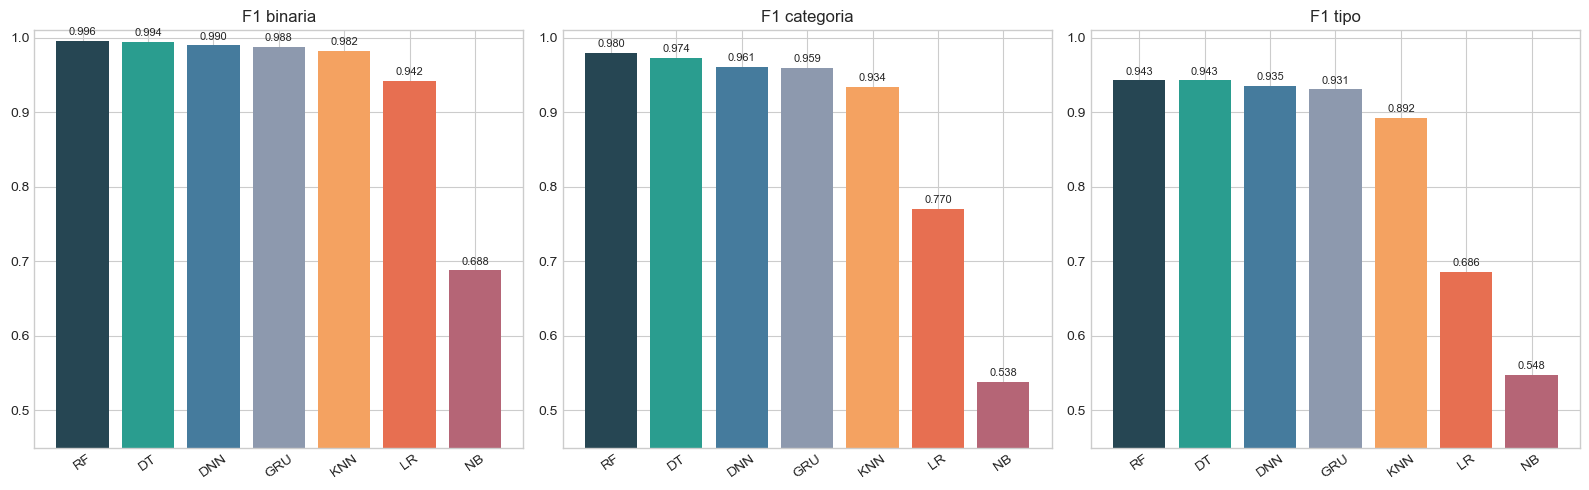

In [8]:
ranking_df = metrics_df[['modelo_corto', 'f1_bin', 'f1_cat', 'f1_type', 'f1_mean']].copy()
display(ranking_df)

ranking_df.to_csv(TABLES_DIR / 'ranking_modelos_f1.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
metric_cols = [('f1_bin', 'F1 binaria'), ('f1_cat', 'F1 categoria'), ('f1_type', 'F1 tipo')]
colors = ['#264653', '#2a9d8f', '#457b9d', '#8d99ae', '#f4a261', '#e76f51', '#b56576']

for ax, (metric_col, title) in zip(axes, metric_cols):
    ax.bar(metrics_df['modelo_corto'], metrics_df[metric_col], color=colors[: len(metrics_df)])
    ax.set_title(title)
    ax.set_ylim(0.45, 1.01)
    ax.tick_params(axis='x', rotation=35)
    for idx, value in enumerate(metrics_df[metric_col]):
        ax.text(idx, value + 0.005, f'{value:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'comparativa_f1_por_tarea.png', dpi=220, bbox_inches='tight')
plt.show()


In [9]:
best_binary = metrics_df.loc[metrics_df['f1_bin'].idxmax(), ['modelo_corto', 'f1_bin']]
best_category = metrics_df.loc[metrics_df['f1_cat'].idxmax(), ['modelo_corto', 'f1_cat']]
best_type = metrics_df.loc[metrics_df['f1_type'].idxmax(), ['modelo_corto', 'f1_type']]
best_global = metrics_df.loc[metrics_df['f1_mean'].idxmax(), ['modelo_corto', 'f1_mean']]

summary_df = pd.DataFrame(
    [
        ['Mejor F1 en binaria', best_binary['modelo_corto'], best_binary['f1_bin']],
        ['Mejor F1 en categoria', best_category['modelo_corto'], best_category['f1_cat']],
        ['Mejor F1 en tipo', best_type['modelo_corto'], best_type['f1_type']],
        ['Mejor promedio global de F1', best_global['modelo_corto'], best_global['f1_mean']],
    ],
    columns=['criterio', 'modelo', 'valor'],
)

summary_text = (
    f"**Mejor F1 en binaria:** {best_binary['modelo_corto']} ({best_binary['f1_bin']:.4f})  \
"
    f"**Mejor F1 en categoria:** {best_category['modelo_corto']} ({best_category['f1_cat']:.4f})  \
"
    f"**Mejor F1 en tipo:** {best_type['modelo_corto']} ({best_type['f1_type']:.4f})  \
"
    f"**Mejor promedio global de F1:** {best_global['modelo_corto']} ({best_global['f1_mean']:.4f})"
)
display(Markdown(summary_text))

summary_df.to_csv(TABLES_DIR / 'resumen_mejores_modelos.csv', index=False)


**Mejor F1 en binaria:** RF (0.9958)  **Mejor F1 en categoria:** RF (0.9798)  **Mejor F1 en tipo:** RF (0.9429)  **Mejor promedio global de F1:** RF (0.9728)

La comparativa global deja una tendencia clara:

1. Los **modelos basados en arboles** dominan la comparativa, especialmente `RF` y `DT`.
2. Entre los modelos profundos, **DNN** supera de forma consistente a **GRU** en el promedio global y en la clasificacion final por tipo.
3. Los modelos lineales o probabilisticos mas simples (`LR`, `NB`) quedan claramente por debajo cuando la tarea requiere separar ataques muy parecidos entre si.


### 6. Analisis detallado de los mejores modelos <a name="6"></a>

Para profundizar en el comportamiento de los modelos, se analizan cuatro casos representativos:

1. **Random Forest (RF)** como mejor modelo global y candidato natural para la fase de interpretabilidad.
2. **Decision Tree (DT)** como segundo mejor modelo global y referencia interpretable basada en arboles.
3. **DNN** como mejor modelo de aprendizaje profundo.
4. **GRU** como segundo modelo profundo y contraste para comprobar si una arquitectura recurrente aporta valor adicional.

En esta seccion se combinan dos vistas complementarias:

1. **Resumen cuantitativo por tipo** mediante precision, recall y F1 macro.
2. **Matrices de confusion normalizadas por categoria**, elegidas porque son suficientemente informativas y a la vez legibles para el lector del notebook.


In [10]:
selected_models = ['RandomForestClassifier', 'DecisionTreeClassifier', 'DNN', 'GRU']
selected_reports = {}

for model_name in selected_models:
    report_df = classification_report_df(real['class1'], model_predictions[model_name])
    selected_reports[model_name] = report_df
    report_df.to_csv(TABLES_DIR / f'reporte_tipo_{model_display_name(model_name)}.csv')

model_summary = metrics_df[metrics_df['modelo'].isin(selected_models)][['modelo_corto', 'prec_type', 'rec_type', 'f1_type', 'f1_mean']]
display(model_summary.sort_values('f1_mean', ascending=False))

model_summary.sort_values('f1_mean', ascending=False).to_csv(TABLES_DIR / 'resumen_modelos_destacados.csv', index=False)


,modelo_corto,prec_type,rec_type,f1_type,f1_mean
0,RF,0.9913,0.9128,0.9429,0.9728
1,DT,0.9550,0.9344,0.9429,0.9702
2,DNN,0.9601,0.9169,0.9355,0.9621
3,GRU,0.9530,0.9176,0.9310,0.9594


#### Matrices de confusion por categoria con anotaciones numericas

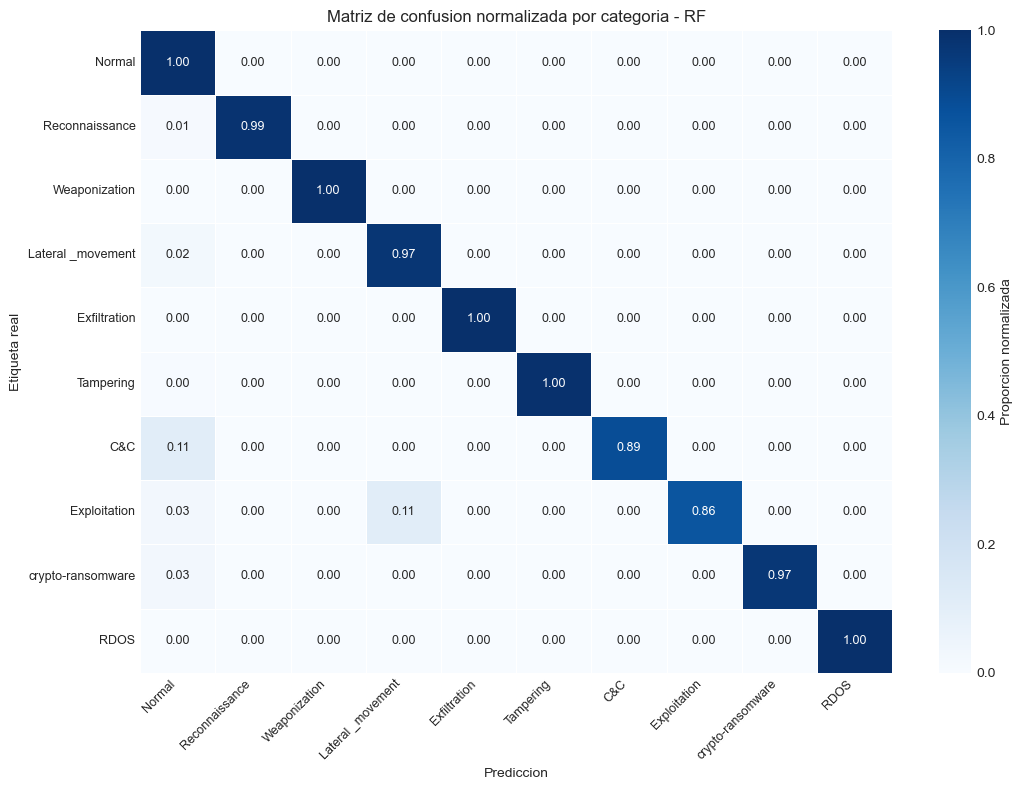

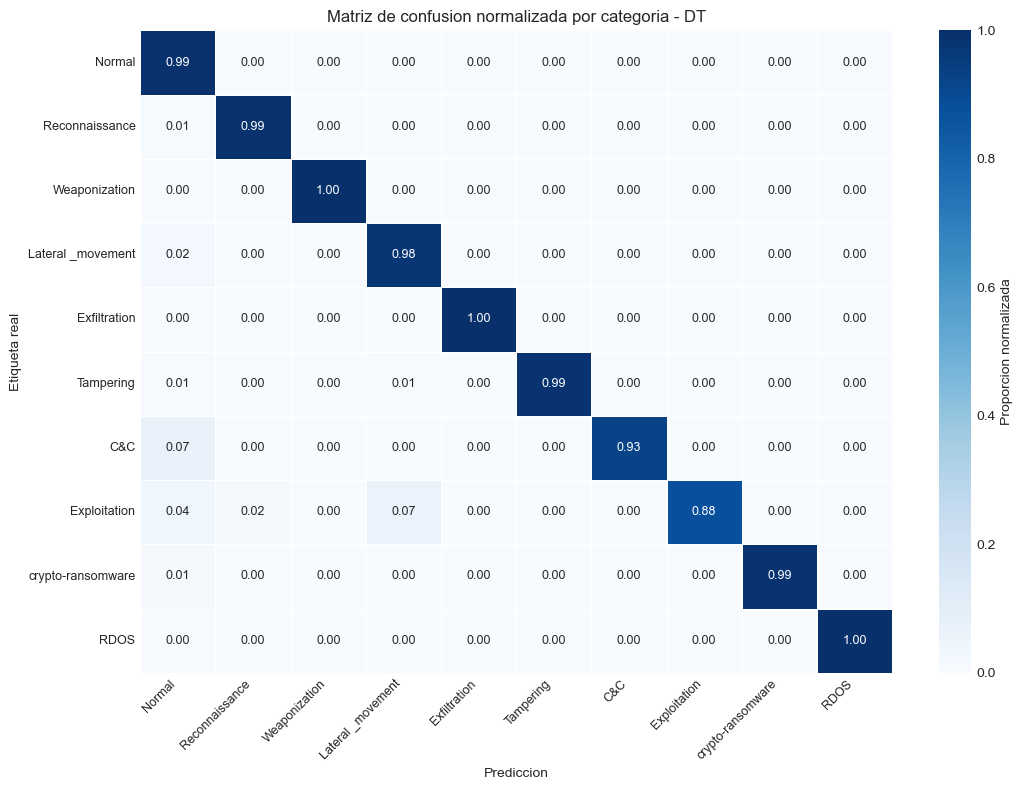

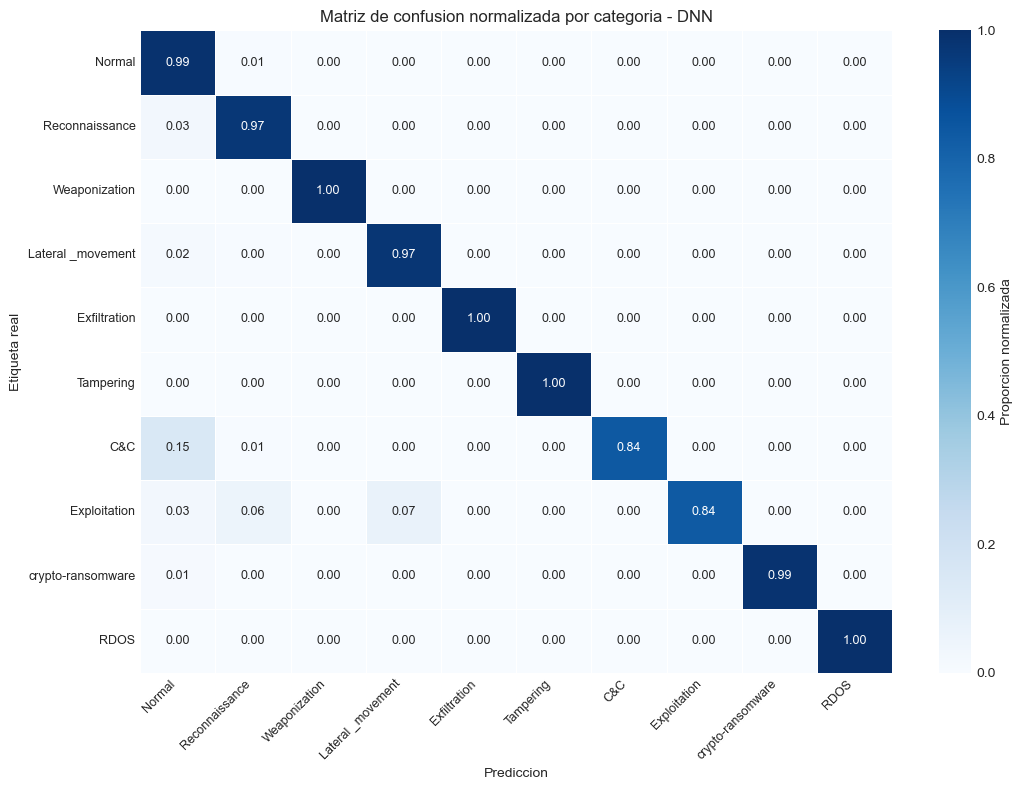

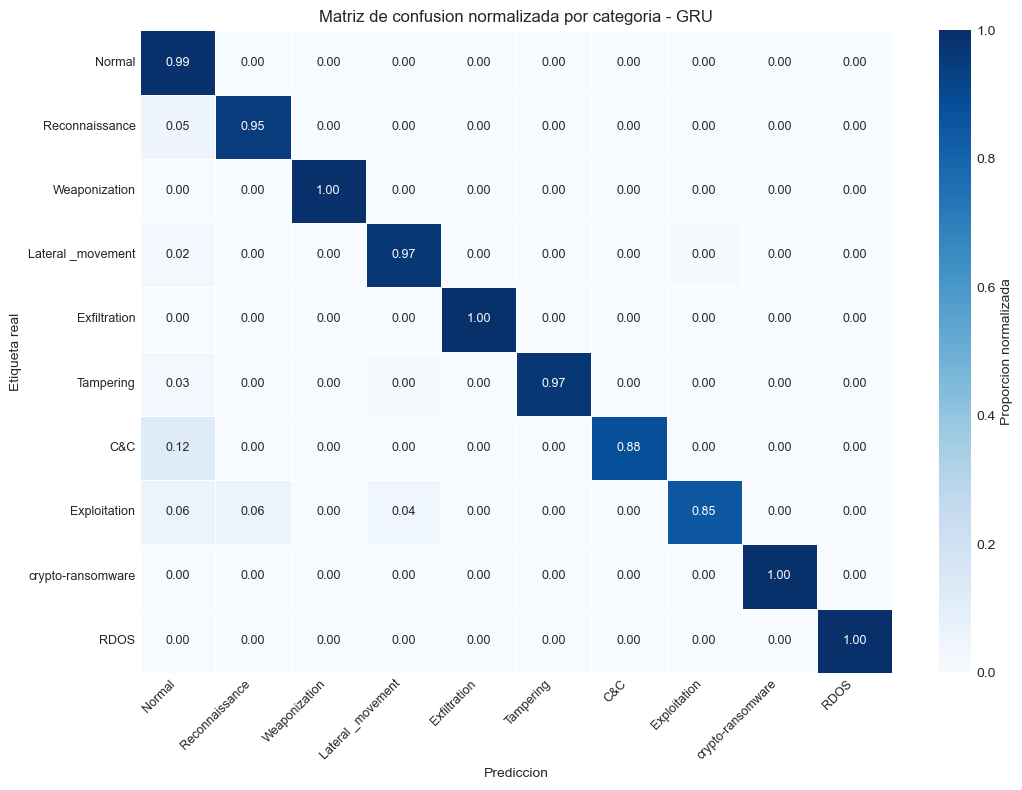

In [11]:
category_labels = ['Normal', 'Reconnaissance', 'Weaponization', 'Lateral _movement', 'Exfiltration', 'Tampering', 'C&C', 'Exploitation', 'crypto-ransomware', 'RDOS']
comparison_models = ['RandomForestClassifier', 'DecisionTreeClassifier', 'DNN', 'GRU']

display(Markdown('#### Matrices de confusion por categoria con anotaciones numericas'))

for model_name in comparison_models:
    pred_type = model_predictions[model_name]
    _, pred_category = derive_outputs(pred_type)
    cm = confusion_matrix(real['class2'], pred_category, labels=category_labels, normalize='true')
    cm_df = pd.DataFrame(cm, index=category_labels, columns=category_labels)
    cm_df.to_csv(TABLES_DIR / f'matriz_confusion_categorias_{model_display_name(model_name)}.csv')

    fig, ax = plt.subplots(figsize=(11, 8))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 9},
        cbar_kws={'label': 'Proporcion normalizada'},
        ax=ax,
    )
    ax.set_title(f'Matriz de confusion normalizada por categoria - {model_display_name(model_name)}')
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Etiqueta real')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f'matriz_confusion_categorias_{model_display_name(model_name)}.png', dpi=220, bbox_inches='tight')
    plt.show()


In [12]:
classes = [
    label
    for label in selected_reports['RandomForestClassifier'].index
    if label not in {'accuracy', 'macro avg', 'weighted avg'}
]

hard_classes = pd.DataFrame(
    {
        'support': selected_reports['RandomForestClassifier'].loc[classes, 'support'].astype(int),
    }
)
for model_name in selected_models:
    hard_classes[f'recall_{model_display_name(model_name)}'] = selected_reports[model_name].loc[classes, 'recall']

hard_classes['mean_recall'] = hard_classes[[col for col in hard_classes.columns if col.startswith('recall_')]].mean(axis=1)
hard_classes = hard_classes.sort_values(['mean_recall', 'support']).head(10)
display(hard_classes)

hard_classes.to_csv(TABLES_DIR / 'clases_mas_dificiles.csv')


,support,recall_RF,recall_DT,recall_DNN,recall_GRU,mean_recall
fuzzing,203,0.4335,0.6847,0.6798,0.5123,0.5776
TCP Relay,326,0.6380,0.6871,0.6963,0.6074,0.6572
Fake_notification,3,0.6667,0.6667,0.6667,1.0000,0.7500
Reverse_shell,146,0.8493,0.8630,0.8356,0.8425,0.8476
C&C,437,0.8902,0.9268,0.8421,0.8810,0.8850
Discovering_resources,3447,0.9684,0.9751,0.8689,0.7702,0.8956
MitM,16,0.9375,1.0000,0.8750,0.8750,0.9219
crypto-ransomware,73,0.9726,0.9863,0.9863,1.0000,0.9863
False_data_injection,751,0.9973,0.9867,0.9987,0.9707,0.9883
Normal,63213,0.9986,0.9941,0.9920,0.9946,0.9948


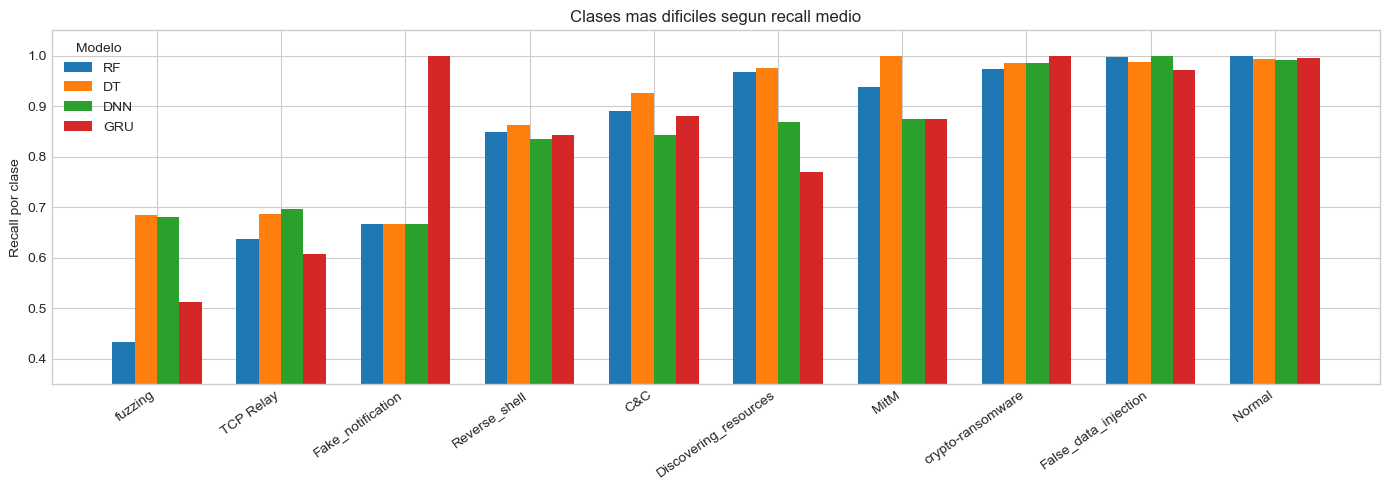

In [13]:
plot_df = hard_classes.reset_index().rename(columns={'index': 'clase'})
recall_cols = [col for col in plot_df.columns if col.startswith('recall_')]

x = np.arange(len(plot_df))
width = 0.18
fig, ax = plt.subplots(figsize=(14, 5))

for idx, col in enumerate(recall_cols):
    ax.bar(x + idx * width - width * 1.5, plot_df[col], width=width, label=col.replace('recall_', ''))

ax.set_xticks(x)
ax.set_xticklabels(plot_df['clase'], rotation=35, ha='right')
ax.set_ylim(0.35, 1.05)
ax.set_ylabel('Recall por clase')
ax.set_title('Clases mas dificiles segun recall medio')
ax.legend(title='Modelo')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'clases_dificiles_recall.png', dpi=220, bbox_inches='tight')
plt.show()


El analisis detallado permite extraer varias conclusiones tecnicas:

1. **Random Forest** ofrece el mejor equilibrio global entre precision, recall y F1, ademas de una ventaja importante en la clasificacion por categoria.
2. **Decision Tree** empata practicamente con `RF` en `F1` por tipo y muestra un recall ligeramente superior en algunas clases raras, pero con menor estabilidad global.
3. **DNN** es el mejor modelo profundo del estudio y se comporta de forma competitiva, aunque sigue por debajo de los mejores modelos de arboles en el promedio general.
4. **GRU** mantiene un rendimiento solido, pero no consigue superar a la DNN en este problema tabular ya preprocesado.
5. Las clases mas conflictivas siguen siendo `fuzzing`, `TCP Relay`, `Reverse_shell` y `C&C`, lo que confirma que el principal desafio no es la deteccion binaria, sino la discriminacion fina entre tipos de ataque con bajo soporte o patrones muy solapados.


### 7. Conclusiones del modelado <a name="7"></a>

Tras analizar y validar la comparativa experimental sobre las particiones preprocesadas del Hito 2, se obtiene una imagen clara del comportamiento de las distintas familias de modelos.

1. **Los modelos basados en arboles son los mas solidos para este problema.** Tanto `Random Forest` como `Decision Tree` superan al resto en la media global de F1, lo que sugiere que el problema esta fuertemente condicionado por relaciones no lineales entre variables tabulares.
2. **Random Forest se selecciona como modelo candidato principal para la fase de interpretabilidad.** No solo logra el mejor promedio global, sino que ademas dispone de mecanismos internos de importancia de variables y es compatible con tecnicas como SHAP y LIME.
3. **La DNN constituye la mejor referencia de aprendizaje profundo.** Aunque no mejora a los mejores modelos de arboles, demuestra que una arquitectura profunda sencilla puede alcanzar resultados competitivos en clasificacion binaria, por categoria y por tipo.
4. **La GRU no aporta ventaja clara en este escenario.** Dado que los datos finales ya se presentan como un vector tabular de 34 caracteristicas agregadas, la estructura secuencial de una GRU no parece explotar informacion adicional suficiente como para justificar su mayor complejidad.
5. **El verdadero cuello de botella esta en las clases poco representadas y muy solapadas.** El comportamiento observado en `fuzzing`, `TCP Relay`, `Reverse_shell` o `C&C` confirma que la dificultad principal reside en la clasificacion multiclase fina, no tanto en la deteccion binaria de anomalias.
